<a href="https://colab.research.google.com/github/Varshini200618/Varshini200618/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Generated Images: Larger Grid of Random Samples

In [13]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch # Added torch import

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 20
num_epochs = 10
batch_size = 128
learning_rate = 1e-3

# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize the images to be between 0 and 1
    # (although Sigmoid in VAE decoder outputs 0-1, it's good practice for input)
    # transforms.Normalize(mean=(0.5,), std=(0.5,)) # Not needed for BCE with Sigmoid output
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Using device: {device}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Using device: cuda
Number of training samples: 60000
Number of test samples: 10000


In [14]:
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: 64x7x7
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: 1x28x28
            nn.Sigmoid() # Output pixels between 0 and 1
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [23]:
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x.view(-1, 784), x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD

### Initialize Model, Optimizer, and Loss History

In [17]:
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = {'total': [], 'recon': [], 'kl': []}

print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Sigmoid()
  )
)


### Initialize Model, Optimizer, and Loss History

In [20]:
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    total_epoch_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device).view(-1, 1, 28, 28) # Ensure correct input shape

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, bce_loss, kld_loss = vae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()
        total_recon_loss += bce_loss.item()
        total_kl_loss += kld_loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], ' +
                  f'Loss: {loss.item() / len(data):.4f}, ' +
                  f'Recon Loss: {bce_loss.item() / len(data):.4f}, ' +
                  f'KL Loss: {kld_loss.item() / len(data):.4f}')

    # Store average epoch losses
    avg_epoch_loss = total_epoch_loss / len(train_dataset)
    avg_recon_loss = total_recon_loss / len(train_dataset)
    avg_kl_loss = total_kl_loss / len(train_dataset)

    history['total'].append(avg_epoch_loss)
    history['recon'].append(avg_recon_loss)
    history['kl'].append(avg_kl_loss)

    print(f'====> Epoch {epoch+1} Average loss: {avg_epoch_loss:.4f}, ' +
          f'Avg Recon Loss: {avg_recon_loss:.4f}, Avg KL Loss: {avg_kl_loss:.4f}')

Epoch [1/10], Batch [100/469], Loss: 163.9154, Recon Loss: 145.8916, KL Loss: 18.0238
Epoch [1/10], Batch [200/469], Loss: 137.2714, Recon Loss: 111.3823, KL Loss: 25.8890
Epoch [1/10], Batch [300/469], Loss: 127.5869, Recon Loss: 101.7807, KL Loss: 25.8062
Epoch [1/10], Batch [400/469], Loss: 114.8396, Recon Loss: 88.9688, KL Loss: 25.8708
====> Epoch 1 Average loss: 155.5394, Avg Recon Loss: 132.5818, Avg KL Loss: 22.9576
Epoch [2/10], Batch [100/469], Loss: 116.2017, Recon Loss: 89.6033, KL Loss: 26.5984
Epoch [2/10], Batch [200/469], Loss: 111.1500, Recon Loss: 84.7515, KL Loss: 26.3985
Epoch [2/10], Batch [300/469], Loss: 113.7032, Recon Loss: 87.2576, KL Loss: 26.4456
Epoch [2/10], Batch [400/469], Loss: 112.4423, Recon Loss: 85.4592, KL Loss: 26.9831
====> Epoch 2 Average loss: 114.4522, Avg Recon Loss: 87.8220, Avg KL Loss: 26.6302
Epoch [3/10], Batch [100/469], Loss: 113.2392, Recon Loss: 86.1107, KL Loss: 27.1285
Epoch [3/10], Batch [200/469], Loss: 105.6203, Recon Loss: 79.4

### Plotting Losses

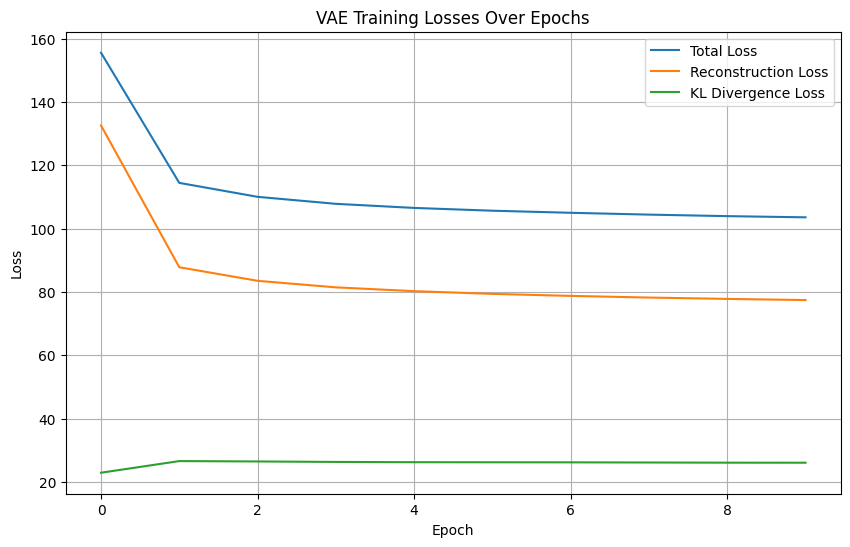

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(history['total'], label='Total Loss')
plt.plot(history['recon'], label='Reconstruction Loss')
plt.plot(history['kl'], label='KL Divergence Loss')
plt.title('VAE Training Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Generate Sample Data Points from Decoder

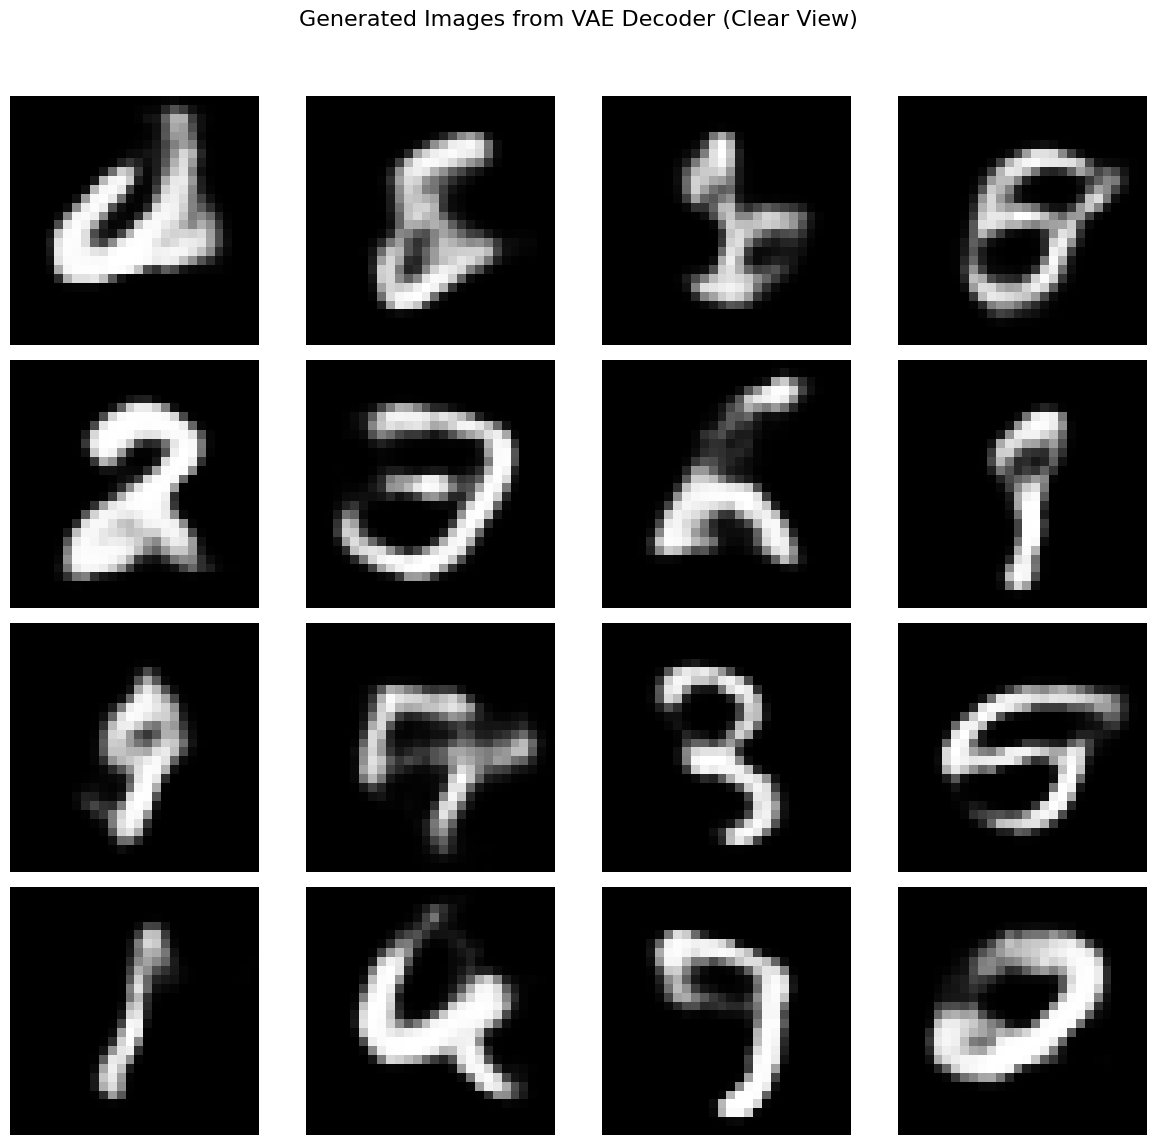

In [28]:
model.eval() # Set model to evaluation mode

with torch.no_grad():
    num_samples = 16 # Reduce number of samples to focus on clarity
    # Generate random latent vectors
    sample = torch.randn(num_samples, latent_dim).to(device)
    # Decode the latent vectors to generate images
    generated_images = model.decoder(model.decoder_input(sample)).cpu()

    # Plot the generated images in a 4x4 grid for better visibility with larger individual images
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12)) # Significantly increased figure size
    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            ax.imshow(generated_images[i].squeeze().numpy(), cmap='gray', interpolation='nearest')
            ax.axis('off')
    plt.suptitle('Generated Images from VAE Decoder (Clear View)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

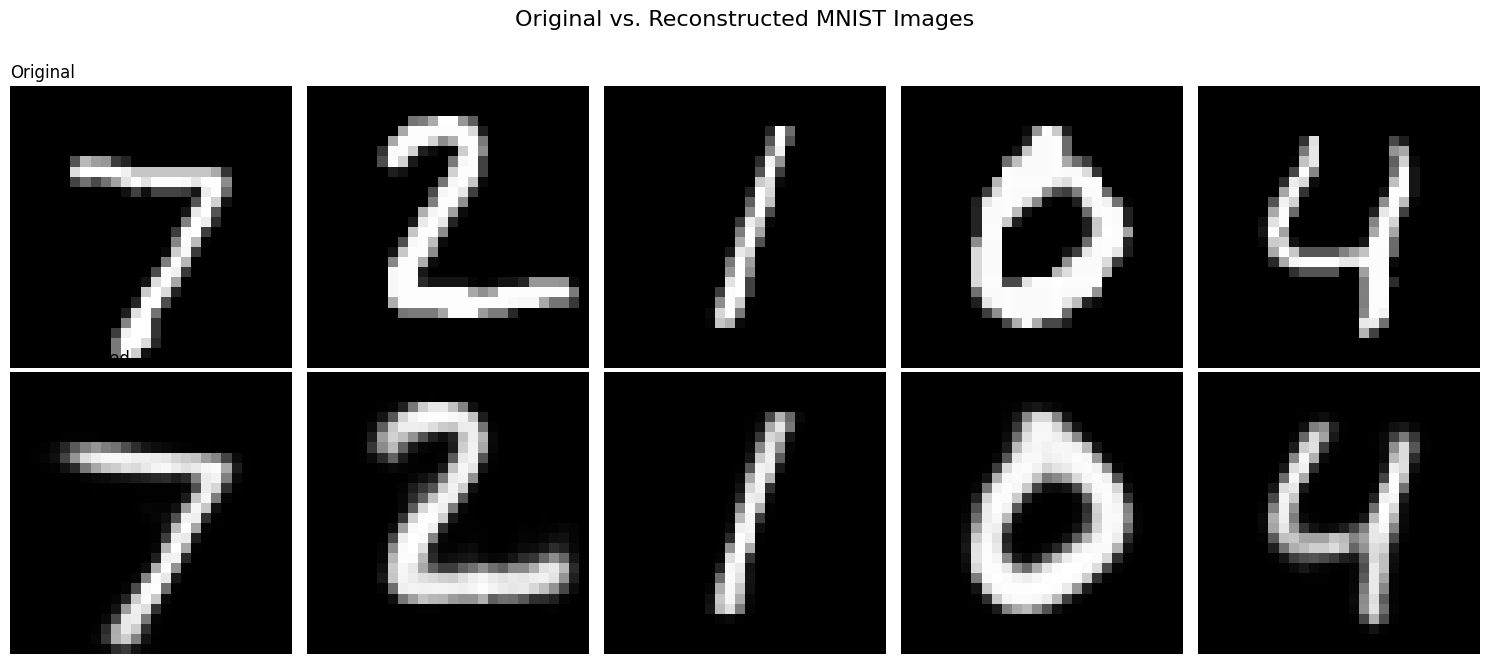

In [29]:
model.eval() # Set model to evaluation mode

with torch.no_grad():
    # Get a batch of test images
    data, _ = next(iter(test_loader))
    data = data.to(device).view(-1, 1, 28, 28)

    # Pass them through the VAE to get reconstructions
    recon_data, _, _ = model(data)

    num_display = 5 # Reduced number of image pairs to display for more clarity
    # Create a figure with 2 rows (original, reconstructed) and num_display columns
    fig, axes = plt.subplots(nrows=2, ncols=num_display, figsize=(3 * num_display, 7)) # Further increased figure size for individual images

    for i in range(num_display):
        # Original images
        ax = axes[0, i]
        ax.imshow(data[i].cpu().squeeze().numpy(), cmap='gray', interpolation='nearest')
        ax.axis('off')
        if i == 0:
            ax.set_title('Original', loc='left')

        # Reconstructed images
        ax = axes[1, i]
        ax.imshow(recon_data[i].cpu().squeeze().numpy(), cmap='gray', interpolation='nearest')
        ax.axis('off')
        if i == 0:
            ax.set_title('Reconstructed', loc='left')

    plt.suptitle('Original vs. Reconstructed MNIST Images', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Conditional Variational Autoencoder (CVAE) Design

In [30]:
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, latent_dim, num_classes, img_channels=1, img_dim=28, embedding_dim=10):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.img_dim = img_dim
        self.embedding_dim = embedding_dim

        # Label Embedding
        self.label_embedding = nn.Embedding(num_classes, embedding_dim)

        # Encoder
        # CNN layers for image processing
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=3, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: 64x7x7
            nn.ReLU(),
            nn.Flatten() # Output: 64 * 7 * 7
        )
        # Linear layers for mu and logvar, now incorporating label embedding
        encoder_output_dim = 64 * 7 * 7
        self.fc_mu = nn.Linear(encoder_output_dim + embedding_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_output_dim + embedding_dim, latent_dim)

        # Decoder
        # Linear layer to combine latent vector and label embedding
        self.decoder_input = nn.Linear(latent_dim + embedding_dim, encoder_output_dim)
        self.decoder_cnn = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1), # Output: 1x28x28
            nn.Sigmoid() # Output pixels between 0 and 1
        )

    def encode(self, x, labels):
        # Embed labels
        label_embed = self.label_embedding(labels)

        # Process image through CNN encoder
        h_cnn = self.encoder_cnn(x)

        # Concatenate CNN output with label embedding
        h_combined = torch.cat([h_cnn, label_embed], dim=1)

        return self.fc_mu(h_combined), self.fc_logvar(h_combined)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        # Embed labels
        label_embed = self.label_embedding(labels)

        # Concatenate latent vector with label embedding
        z_combined = torch.cat([z, label_embed], dim=1)

        # Pass through decoder input linear layer and then CNN decoder
        h = self.decoder_input(z_combined)
        return self.decoder_cnn(h)

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, labels), mu, logvar

### CVAE Loss Function
The loss function for CVAE remains the same as for VAE, combining Binary Cross-Entropy for reconstruction and KL divergence for regularization.

In [31]:
def cvae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x.view(-1, 784), x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD

### Initialize CVAE Model, Optimizer, and Loss History

In [32]:
num_classes = 10 # For MNIST (digits 0-9)
embedding_dim = 10 # Dimension for label embedding

cvae_model = CVAE(latent_dim=latent_dim, num_classes=num_classes, embedding_dim=embedding_dim).to(device)
cvae_optimizer = torch.optim.Adam(cvae_model.parameters(), lr=learning_rate)

cvae_history = {'total': [], 'recon': [], 'kl': []}

print(cvae_model)

CVAE(
  (label_embedding): Embedding(10, 10)
  (encoder_cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3146, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3146, out_features=20, bias=True)
  (decoder_input): Linear(in_features=30, out_features=3136, bias=True)
  (decoder_cnn): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Sigmoid()
  )
)


### CVAE Training Loop

In [33]:
for epoch in range(num_epochs):
    cvae_model.train() # Set model to training mode
    total_epoch_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device).view(-1, 1, 28, 28)
        labels = labels.to(device) # Move labels to device

        cvae_optimizer.zero_grad()
        recon_batch, mu, logvar = cvae_model(data, labels)
        loss, bce_loss, kld_loss = cvae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        cvae_optimizer.step()

        total_epoch_loss += loss.item()
        total_recon_loss += bce_loss.item()
        total_kl_loss += kld_loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], ' +
                  f'Loss: {loss.item() / len(data):.4f}, ' +
                  f'Recon Loss: {bce_loss.item() / len(data):.4f}, ' +
                  f'KL Loss: {kld_loss.item() / len(data):.4f}')

    # Store average epoch losses
    avg_epoch_loss = total_epoch_loss / len(train_dataset)
    avg_recon_loss = total_recon_loss / len(train_dataset)
    avg_kl_loss = total_kl_loss / len(train_dataset)

    cvae_history['total'].append(avg_epoch_loss)
    cvae_history['recon'].append(avg_recon_loss)
    cvae_history['kl'].append(avg_kl_loss)

    print(f'====> Epoch {epoch+1} Average loss: {avg_epoch_loss:.4f}, ' +
          f'Avg Recon Loss: {avg_recon_loss:.4f}, Avg KL Loss: {avg_kl_loss:.4f}')

Epoch [1/10], Batch [100/469], Loss: 166.0593, Recon Loss: 151.4188, KL Loss: 14.6405
Epoch [1/10], Batch [200/469], Loss: 138.0759, Recon Loss: 119.9786, KL Loss: 18.0973
Epoch [1/10], Batch [300/469], Loss: 122.4160, Recon Loss: 100.9389, KL Loss: 21.4770
Epoch [1/10], Batch [400/469], Loss: 116.9992, Recon Loss: 94.4750, KL Loss: 22.5242
====> Epoch 1 Average loss: 153.7833, Avg Recon Loss: 134.3634, Avg KL Loss: 19.4199
Epoch [2/10], Batch [100/469], Loss: 111.8083, Recon Loss: 88.7522, KL Loss: 23.0561
Epoch [2/10], Batch [200/469], Loss: 107.5609, Recon Loss: 85.4749, KL Loss: 22.0860
Epoch [2/10], Batch [300/469], Loss: 113.6141, Recon Loss: 90.2061, KL Loss: 23.4081
Epoch [2/10], Batch [400/469], Loss: 111.7041, Recon Loss: 87.8437, KL Loss: 23.8604
====> Epoch 2 Average loss: 110.3518, Avg Recon Loss: 87.3223, Avg KL Loss: 23.0296
Epoch [3/10], Batch [100/469], Loss: 106.1017, Recon Loss: 82.8322, KL Loss: 23.2695
Epoch [3/10], Batch [200/469], Loss: 102.7078, Recon Loss: 80.5

### Plotting CVAE Losses

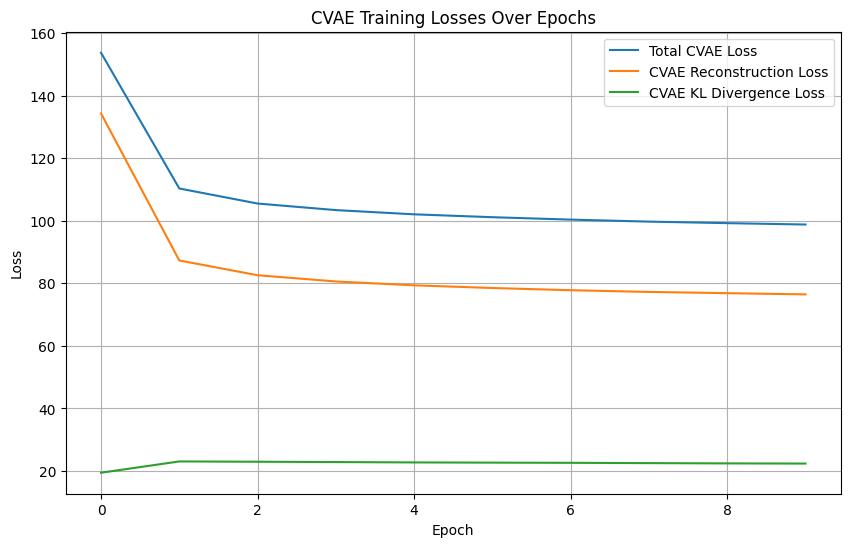

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(cvae_history['total'], label='Total CVAE Loss')
plt.plot(cvae_history['recon'], label='CVAE Reconstruction Loss')
plt.plot(cvae_history['kl'], label='CVAE KL Divergence Loss')
plt.title('CVAE Training Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/20
Total Loss: 117.0315
Recon Loss: 98.3164
KL Loss: 37.4302
Epoch 2/20
Total Loss: 89.6372
Recon Loss: 71.2051
KL Loss: 36.8642
Epoch 3/20
Total Loss: 86.8497
Recon Loss: 68.8610
KL Loss: 35.9772
Epoch 4/20
Total Loss: 85.4176
Recon Loss: 67.7050
KL Loss: 35.4252
Epoch 5/20
Total Loss: 84.5487
Recon Loss: 67.0384
KL Loss: 35.0207
Epoch 6/20
Total Loss: 83.8323
Recon Loss: 66.4975
KL Loss: 34.6695
Epoch 7/20
Total Loss: 83.2778
Recon Loss: 66.1129
KL Loss: 34.3298
Epoch 8/20
Total Loss: 82.7242
Recon Loss: 65.6733
KL Loss: 34.1018
Epoch 9/20
Total Loss: 82.3980
Recon Loss: 65.4470
KL Loss: 33.9019
Epoch 10/20
Total Loss: 81.9900
Recon Loss: 65.1677
KL Loss: 33.6447
Epoch 11/20
Total Loss: 81.7232
Recon Loss: 64.9885
KL Loss: 33.4695
Epoch 12/20
Total Loss: 81.4335
Recon Loss: 64.7778
KL Loss: 33.3115
Epoch 13/20
Total Loss: 81.1624
Recon Loss: 64.5836
KL Loss: 33.1576
Epoch 14/20
Total Loss: 80.9074
Recon Loss: 64.4032
KL Loss: 33.0084
Epoch 15/20
Total Loss: 80.7206
Recon Loss

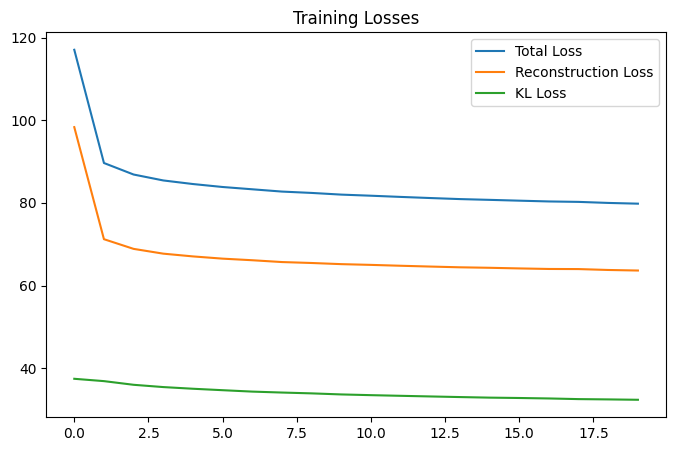

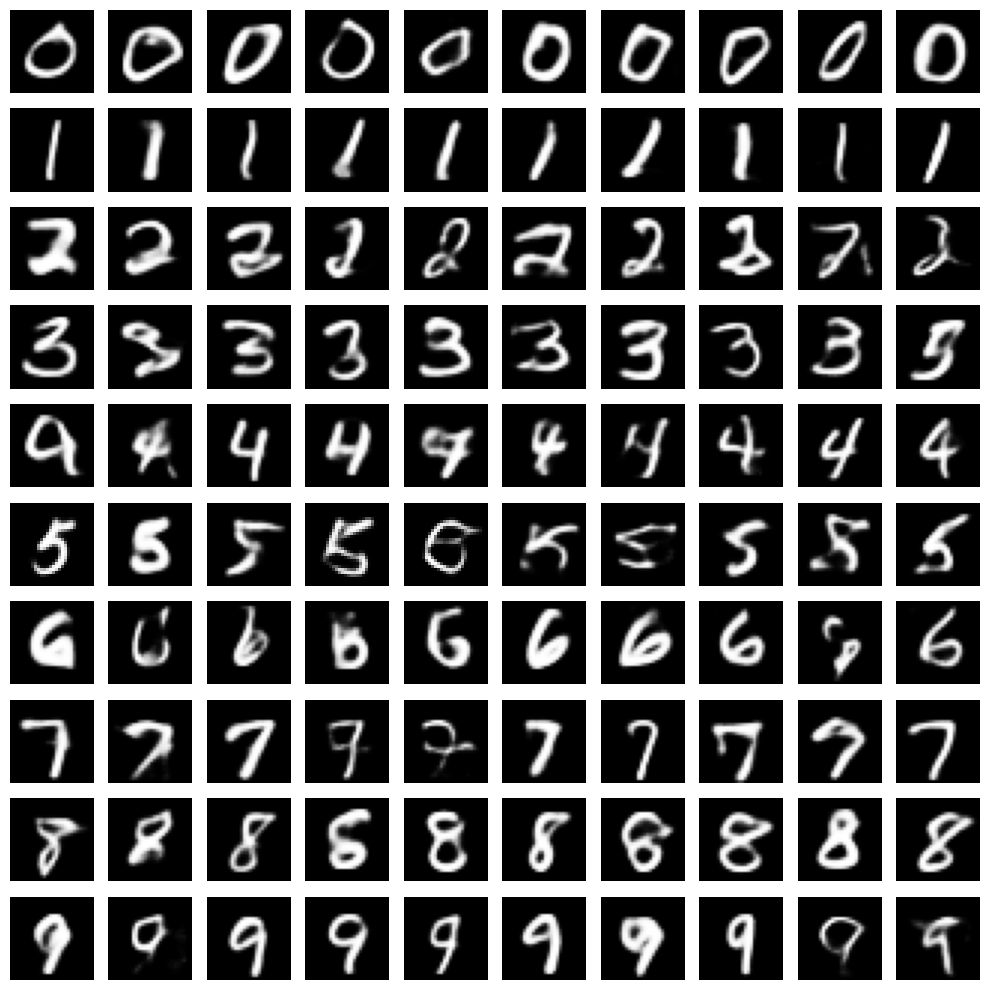

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Hyperparameters
# -------------------------
batch_size = 128
latent_dim = 64          # larger latent space
embedding_dim = 20
num_classes = 10
epochs = 20
lr = 1e-3
beta = 0.5               # lower KL weight → sharper images

# -------------------------
# Dataset
# -------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# -------------------------
# Encoder
# -------------------------
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(num_classes, embedding_dim)
        # Add a linear layer to project embedding_dim to a 28x28 map
        self.label_proj = nn.Linear(embedding_dim, 28 * 28)

        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 4, 2, 1), # Input channels changed to 2 (1 for image + 1 for label_map)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*7*7, latent_dim)
        self.fc_logvar = nn.Linear(128*7*7, latent_dim)

    def forward(self, x, labels):
        label_embed = self.embedding(labels)

        # Project the label embedding to a 28x28 map
        label_map = self.label_proj(label_embed)
        label_map = label_map.view(x.size(0), 1, 28, 28) # Reshape to [batch_size, 1, 28, 28]

        x = torch.cat([x, label_map], dim=1) # Concatenate along channel dimension

        h = self.conv(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar


# -------------------------
# Decoder
# -------------------------
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(num_classes, embedding_dim)

        self.fc = nn.Linear(latent_dim + embedding_dim, 128*7*7)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z, labels):
        label_embed = self.embedding(labels)

        x = torch.cat([z, label_embed], dim=1)

        h = self.fc(x)
        h = h.view(-1, 128, 7, 7)

        return self.deconv(h)


# -------------------------
# CVAE
# -------------------------
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, labels):
        mu, logvar = self.encoder(x, labels)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, labels)
        return recon, mu, logvar


model = CVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

# -------------------------
# Loss
# -------------------------
def loss_function(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


# -------------------------
# Training
# -------------------------
total_losses = []
recon_losses = []
kl_losses = []

for epoch in range(epochs):
    model.train()

    total_epoch = 0
    recon_epoch = 0
    kl_epoch = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(images, labels)
        loss, recon_loss, kl_loss = loss_function(
            recon, images, mu, logvar
        )

        loss.backward()
        optimizer.step()

        total_epoch += loss.item()
        recon_epoch += recon_loss.item()
        kl_epoch += kl_loss.item()

    total_losses.append(total_epoch/len(train_dataset))
    recon_losses.append(recon_epoch/len(train_dataset))
    kl_losses.append(kl_epoch/len(train_dataset))

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Total Loss: {total_losses[-1]:.4f}")
    print(f"Recon Loss: {recon_losses[-1]:.4f}")
    print(f"KL Loss: {kl_losses[-1]:.4f}")


# -------------------------
# Plot Losses
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(total_losses, label='Total Loss')
plt.plot(recon_losses, label='Reconstruction Loss')
plt.plot(kl_losses, label='KL Loss')
plt.legend()
plt.title("Training Losses")
plt.show()


# -------------------------
# Generate 10 samples/class
# -------------------------
model.eval()

generated_images = []

with torch.no_grad():
    for digit in range(10):
        labels = torch.tensor([digit]*10).to(device)
        z = torch.randn(10, latent_dim).to(device)

        samples = model.decoder(z, labels)
        generated_images.append(samples.cpu())

generated_images = torch.cat(generated_images)

# -------------------------
# Plot Generated Samples
# -------------------------
fig, axes = plt.subplots(10,10, figsize=(10,10))

idx = 0
for i in range(10):
    for j in range(10):
        axes[i,j].imshow(
            generated_images[idx].squeeze(),
            cmap='gray'
        )
        axes[i,j].axis('off')
        idx += 1

plt.tight_layout()
plt.show()